# 01 Phan tich Du lieu Kham pha (EDA) - Phan tich HR

Notebook nay kham pha the HR dataset to understand factors influencing su tu chuc cua nhan vien (left).

In [9]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yaml

# Them src vao duong dan
sys.path.append(os.path.abspath('../'))

from src.data.loader import load_data, load_config
from src.data.cleaner import clean_data
from src.visualization.plots import plot_target_distribution, plot_correlation_heatmap, plot_categorical_vs_target, plot_numerical_distributions

In [10]:
# Tai cau hinh va du lieu
config = load_config('../configs/params.yaml')
df_raw = load_data('../' + config['raw_data_path'])
print(f"Kich thuoc tap du lieu: {df_raw.shape}")
df_raw.head()

Dataset shape: (1480, 38)


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [11]:
# Lam sach Du lieu
df = clean_data(df_raw)
print(f"Kich thuoc sau lam sach (removing duplicates): {df.shape}")
df.info()

Shape after cleaning (removing duplicates): (1473, 39)
<class 'pandas.core.frame.DataFrame'>
Index: 1473 entries, 0 to 1479
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   empid                     1473 non-null   object 
 1   age                       1473 non-null   int64  
 2   agegroup                  1473 non-null   object 
 3   attrition                 1473 non-null   object 
 4   businesstravel            1473 non-null   object 
 5   dailyrate                 1473 non-null   int64  
 6   department                1473 non-null   object 
 7   distancefromhome          1473 non-null   int64  
 8   education                 1473 non-null   int64  
 9   educationfield            1473 non-null   object 
 10  employeecount             1473 non-null   int64  
 11  employeenumber            1473 non-null   int64  
 12  environmentsatisfaction   1473 non-null   int64  
 13  gender       

## 1. Phan phoi Muc tieu

f:\DLL moi(cu)\src\visualization\plots.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


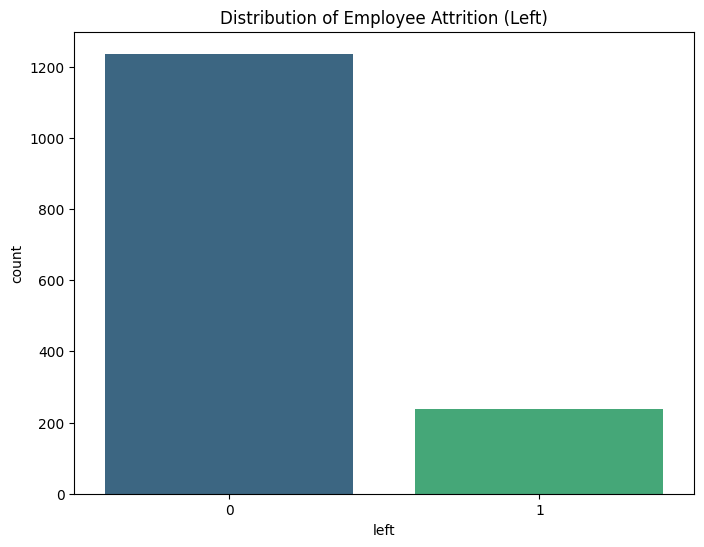

In [12]:
plot_target_distribution(df)

## 2. Phan phoi Cac Tinh nang So

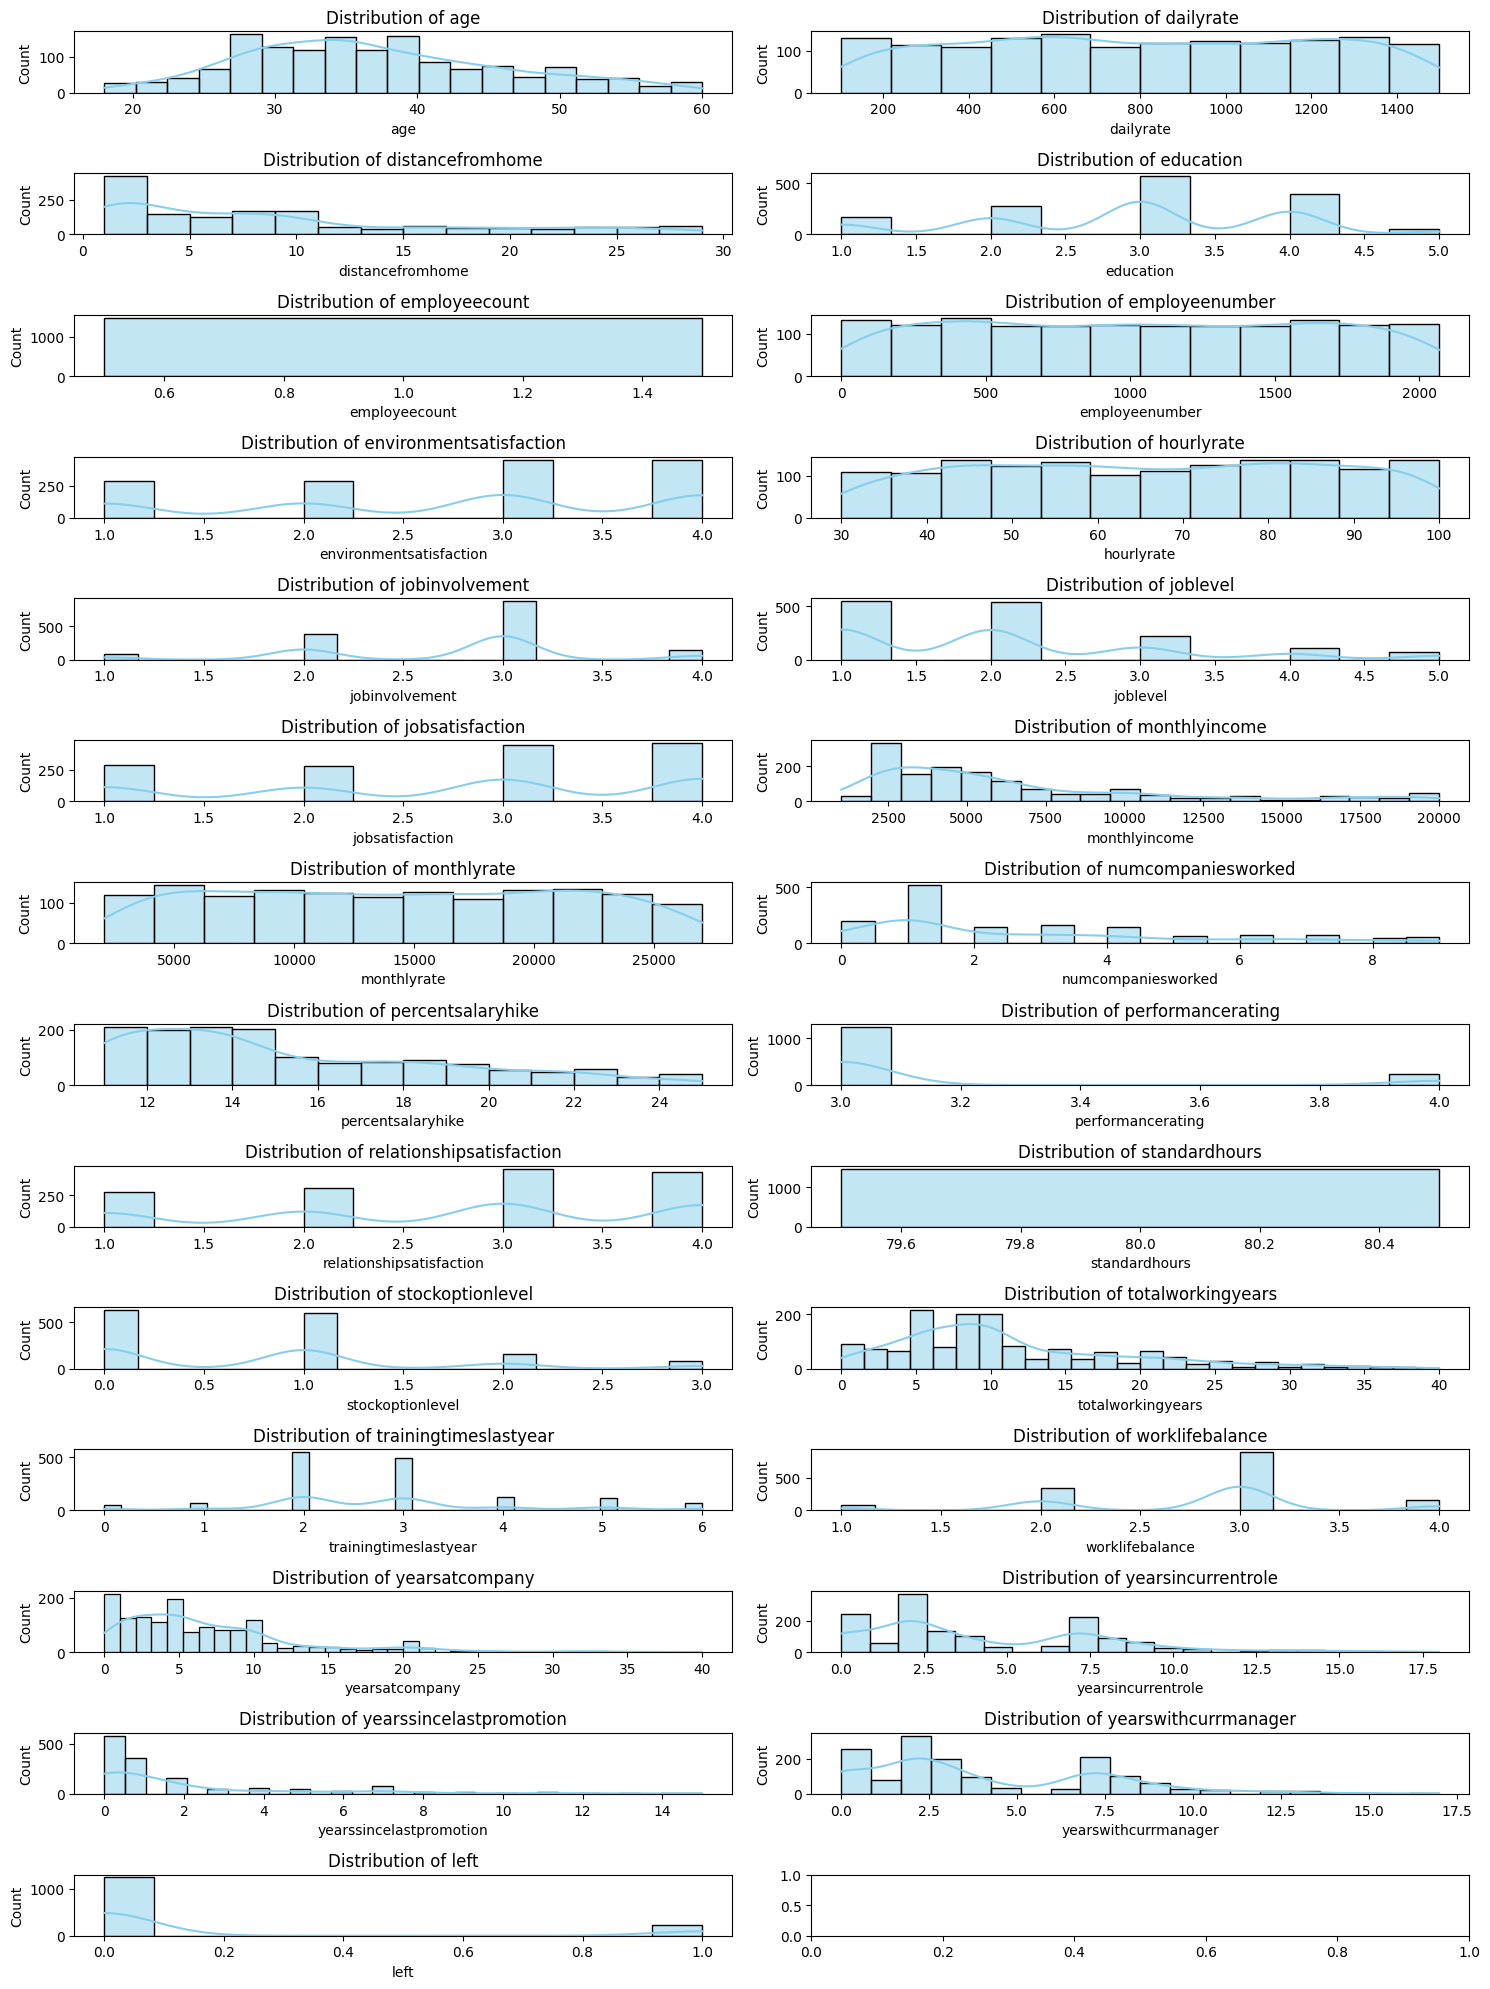

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
plot_numerical_distributions(df, num_cols)

## 3. Phan loai (Bo phan va Luong) so voi Tu chuc

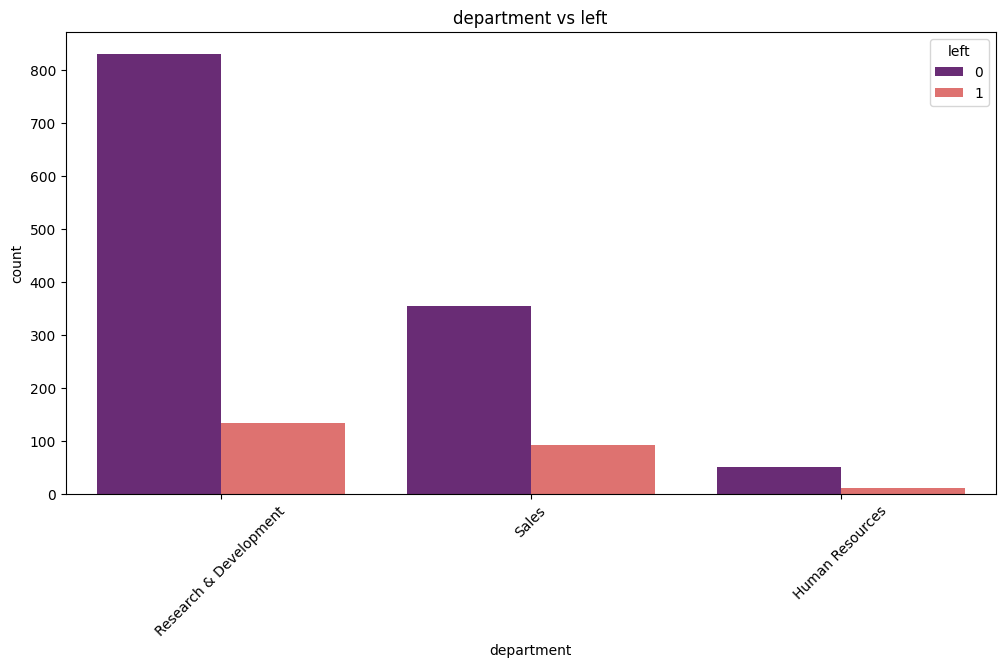

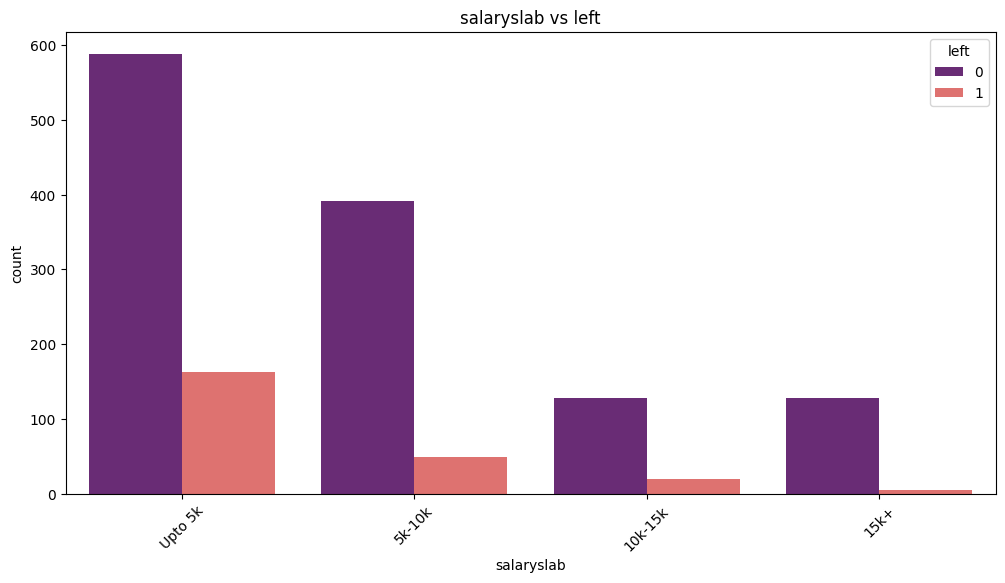

In [14]:
plot_categorical_vs_target(df, 'department')
plot_categorical_vs_target(df, 'salaryslab')

## 4. Phan tich Tuong quan

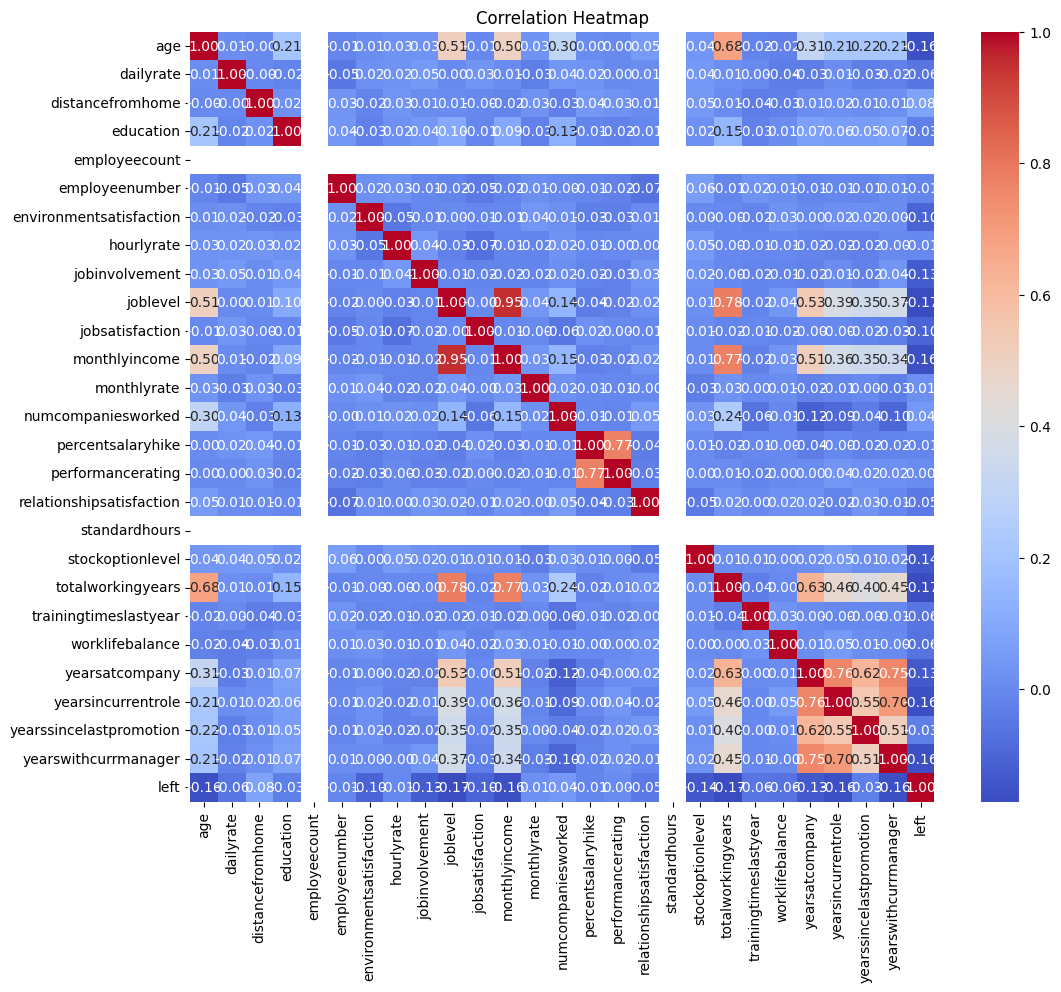

In [15]:
plot_correlation_heatmap(df)